# W–B nanocluster stability and fragmentation maps

This notebook reproduces the stability map and fragmentation-energy map for $\mathrm{W}_m\mathrm{B}_n$ nanoclusters.

Required files in the working directory:

- `WB_with_pure.txt` — total-energy table for $\mathrm{W}_m\mathrm{B}_n$  compositions;
- `tools_stability/` — Python package containing `frag.py`, `exchange_within_pairs.py`, and `aux_routines.py`.

The notebook exports processed CSV files and publication figures to `stability_map_outputs/`.

Methodological basis:

S. V. Lepeshkin, V. S. Baturin, Yu. A. Uspenskii, and A. R. Oganov,  
“Method for Simultaneous Prediction of Atomic Structure and Stability of Nanoclusters in a Wide Area of Compositions,”  
*Journal of Physical Chemistry Letters* **2019**, *10*, 102–106.  
DOI: `10.1021/acs.jpclett.8b03510`.

## Imports

In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import matplotlib.patheffects as pe

from tools_stability import frag, exchange_within_pairs
from tools_stability.aux_routines import list_fmt2table, table2list_fmt

# Global plotting style
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
mpl.rcParams["axes.unicode_minus"] = False

General utils package


In [3]:
# =========================================================
# Input/output paths and selected compositions
# =========================================================
INPUT_FILE = Path("WB_with_pure.txt")
OUTPUT_DIR = Path("stability_map_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# True if the energy table includes pure-W and pure-B borders, i.e. indices start from 0.
PURE_INCLUDED = True

# Compositions selected beforehand for subsequent adsorption and NEB calculations.
# These labels are used only to mark the selected points on the maps
# and to extract their stability and fragmentation values.
SELECTED_LABELS = [
    "WB9", "WB16", "WB18",
    "W2B6", "W2B8", "W2B16",
    "W3B12",
    "W7B20", "W7B24",
    "W8B10",
    "W9B9", "W9B20", "W9B22",
    "W10B21",
    "W11B22",
    "W14B19",
    "W16B19",
    "W17B2", "W17B14", "W17B17",
    "W18B9",
]

## Helper functions

This section defines auxiliary functions used for plotting maps, parsing composition labels, filtering selected compositions, and exporting calculated values to CSV tables.

In [4]:
# =========================================================
# Helper functions
# =========================================================
def make_edges(vals):
    # Convert axis-center values to cell-edge values for pcolormesh.
    vals = np.asarray(vals, dtype=float)
    if len(vals) == 1:
        return np.array([vals[0] - 0.5, vals[0] + 0.5])

    step = np.diff(vals)
    if not np.allclose(step, step[0]):
        raise ValueError("Axis values are not equally spaced.")

    d = step[0]
    return np.concatenate(([vals[0] - d / 2], vals[:-1] + d / 2, [vals[-1] + d / 2]))


def parse_wb_formula(label):
    # Parse formula labels: WB9 -> (1, 9), W2B6 -> (2, 6).
    match = re.fullmatch(r"W(\d*)B(\d+)", label.strip())
    if not match:
        raise ValueError(f"Cannot parse label: {label}")

    w_part = match.group(1)
    b_part = match.group(2)
    m_w = int(w_part) if w_part else 1
    n_b = int(b_part)
    return m_w, n_b


def filter_selected_points(selected_labels, w_axis, b_axis):
    # Return selected points present on a given W/B map and those missing from it.
    selected_points = [parse_wb_formula(label) for label in selected_labels]

    selected_on_map = []
    missing_points = []

    for m_w, n_b in selected_points:
        if (m_w in w_axis) and (n_b in b_axis):
            selected_on_map.append((m_w, n_b))
        else:
            missing_points.append((m_w, n_b))

    return selected_on_map, missing_points


def matrix_to_csv(matrix, w_axis, b_axis, path):
    # Save a W-by-B matrix as a labeled CSV table.
    df = pd.DataFrame(matrix, index=w_axis, columns=b_axis)
    df.index.name = "m_W"
    df.columns.name = "n_B"
    df.to_csv(path)
    return df


def selected_values_to_dataframe(selected_points, matrix, w_axis, b_axis, value_name):
    # Collect map values for selected W/B compositions.
    rows = []
    for m_w, n_b in selected_points:
        i = np.where(w_axis == m_w)[0][0]
        j = np.where(b_axis == n_b)[0][0]
        rows.append({
            "m_W": int(m_w),
            "n_B": int(n_b),
            "formula": f"W{int(m_w)}B{int(n_b)}" if int(m_w) != 1 else f"WB{int(n_b)}",
            value_name: float(matrix[i, j]),
        })
    return pd.DataFrame(rows)

## 1. Load $\mathrm{W}_m\mathrm{B}_n$ energy table

In [5]:
en_table = np.loadtxt(INPUT_FILE)

if PURE_INCLUDED:
    nw = len(en_table) - 1
    nb = len(en_table[0]) - 1
    w_row = np.arange(0, nw + 1)
    b_row = np.arange(0, nb + 1)
else:
    nw = len(en_table)
    nb = len(en_table[0])
    w_row = np.arange(1, nw + 1)
    b_row = np.arange(1, nb + 1)

print("Energy table shape:", en_table.shape)
print("W axis:", w_row)
print("B axis:", b_row)

# Convert table to list format: [[m0, n0, E0], [m1, n1, E1], ...]
fmt_data = table2list_fmt(w_row, b_row, en_table)

Energy table shape: (21, 26)
W axis: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
B axis: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


## 2. Calculate stability descriptor $\Delta_{\min}(n,m)$


The local compositional stability of each $\mathrm{W}_m\mathrm{B}_n$ cluster is evaluated using the second-order finite-difference descriptor $\Delta_{\min}(m,n)$, as described in the manuscript. The descriptor is calculated from the ground-state energy table using the `exchange_within_pairs.min_d2e_nd` routine from `tools_stability`.

Positive values of $\Delta_{\min}(m,n)$ correspond to compositions that are locally favored relative to neighboring stoichiometries, while negative values indicate reduced local compositional stability. Because the second finite difference requires neighboring compositions, the outer border of the energy table is excluded from the resulting map.

In [6]:
min_d2E = exchange_within_pairs.min_d2e_nd(
    fmt_data,
    out_asmatrix=True,
    ignore_nonexistent_shifts=False,
)

# For the second finite difference, edge compositions are removed.
w_row_trunc = w_row[1:-1]
b_row_trunc = b_row[1:-1]

print("min_d2E shape:", min_d2E.shape)
print("len(w_row_trunc):", len(w_row_trunc))
print("len(b_row_trunc):", len(b_row_trunc))
print("min_d2E min:", np.nanmin(min_d2E))
print("min_d2E max:", np.nanmax(min_d2E))

min_d2E_df = matrix_to_csv(
    min_d2E,
    w_row_trunc,
    b_row_trunc,
    OUTPUT_DIR / "min_d2E_matrix.csv",
)

selected_on_stability, missing_from_stability = filter_selected_points(
    SELECTED_LABELS,
    w_row_trunc,
    b_row_trunc,
)

print("\nSelected compositions on stability map:")
for point in selected_on_stability:
    print(point)

if missing_from_stability:
    print("\nSelected compositions not present on stability map:")
    for point in missing_from_stability:
        print(point)

min_d2E shape: (19, 24)
len(w_row_trunc): 19
len(b_row_trunc): 24
min_d2E min: -8.425700000000006
min_d2E max: 7.011700000000019

Selected compositions on stability map:
(1, 9)
(1, 16)
(1, 18)
(2, 6)
(2, 8)
(2, 16)
(3, 12)
(7, 20)
(7, 24)
(8, 10)
(9, 9)
(9, 20)
(9, 22)
(10, 21)
(11, 22)
(14, 19)
(16, 19)
(17, 2)
(17, 14)
(17, 17)
(18, 9)


## 3. Plot stability map

Only the final publication colormap is kept in this notebook.

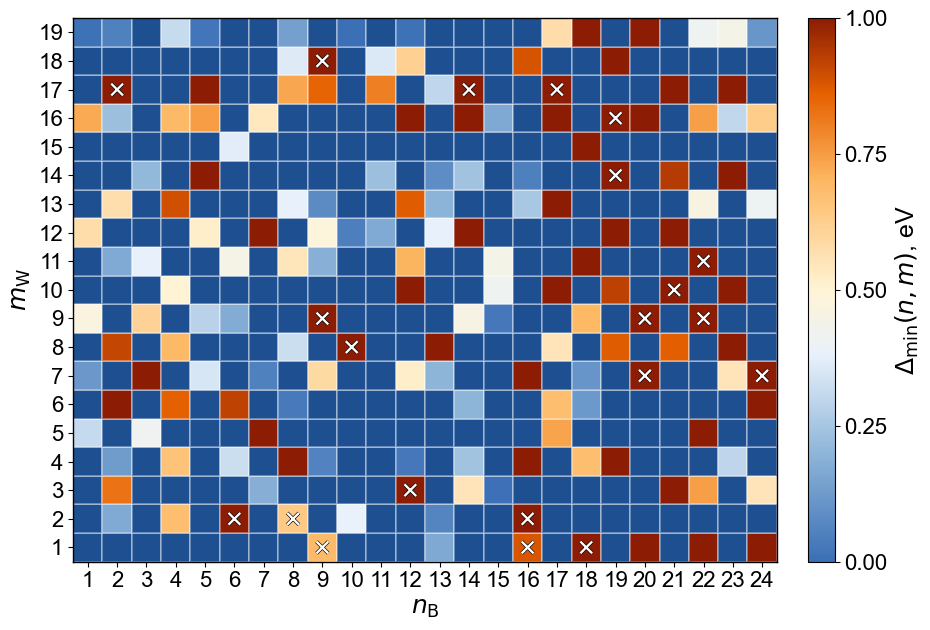

In [7]:
# =========================================================
# Final stability colormap
# =========================================================
stability_cmap = LinearSegmentedColormap.from_list(
    "wb_stability_soft",
    [
        (0.00, "#3b6fb6"),
        (0.20, "#8fb6d9"),
        (0.38, "#e8f1fb"),
        (0.50, "#fff4d6"),
        (0.70, "#fdb863"),
        (0.86, "#e66101"),
        (1.00, "#8c1d04"),
    ],
)
stability_cmap.set_under("#1d4f91")

x_edges_stability = make_edges(b_row_trunc)
y_edges_stability = make_edges(w_row_trunc)

fig, ax = plt.subplots(figsize=(9.4, 6.4))

mesh = ax.pcolormesh(
    x_edges_stability,
    y_edges_stability,
    min_d2E,
    cmap=stability_cmap,
    vmin=0.0,
    vmax=1.0,
    shading="flat",
    edgecolors=(1, 1, 1, 0.35),
    linewidth=0.08,
    antialiased=False,
)

ax.set_xticks(b_row_trunc)
ax.set_yticks(w_row_trunc)
ax.set_xlabel(r"$n_{\mathrm{B}}$", fontsize=18)
ax.set_ylabel(r"$m_{\mathrm{W}}$", fontsize=18)
ax.tick_params(axis="both", labelsize=16)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

if selected_on_stability:
    x_sel = [n_b for (m_w, n_b) in selected_on_stability]
    y_sel = [m_w for (m_w, n_b) in selected_on_stability]

    sc = ax.scatter(
        x_sel,
        y_sel,
        marker="x",
        s=72,
        linewidths=1.7,
        color="white",
        zorder=6,
    )
    sc.set_path_effects([
        pe.Stroke(linewidth=2.6, foreground="black"),
        pe.Normal(),
    ])

cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"$\Delta_{\min}(n,m)$, eV", fontsize=18)
cbar.ax.tick_params(labelsize=16)
cbar.set_ticks([0.00, 0.25, 0.50, 0.75, 1.00])

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "stability_map.png", dpi=600, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "stability_map.pdf", bbox_inches="tight")
plt.show()

In [8]:
selected_stability_df = selected_values_to_dataframe(
    selected_on_stability,
    min_d2E,
    w_row_trunc,
    b_row_trunc,
    "min_d2E_eV",
)

selected_stability_df.to_csv(OUTPUT_DIR / "selected_stability_values.csv", index=False)
selected_stability_df

,m_W,n_B,formula,min_d2E_eV
0,1,9,WB9,0.6902
1,1,16,WB16,0.8827
2,1,18,WB18,1.6255
3,2,6,W2B6,1.2116
4,2,8,W2B8,0.6438
5,2,16,W2B16,1.9726
6,3,12,W3B12,1.7802
7,7,20,W7B20,2.8297
8,7,24,W7B24,2.7617
9,8,10,W8B10,2.2643


## 4. Fragmentation energy analysis
The fragmentation stability of $\mathrm{W}_m\mathrm{B}_n$ nanoclusters was evaluated by calculating the minimum energy required to decompose each parent cluster into two smaller W--B fragments. For a given composition $\mathrm{W}_m\mathrm{B}_n$, all possible binary fragmentation channels were considered:

$$
W_mB_n \rightarrow W_{m_1}B_{n_1} + W_{m_2}B_{n_2},
$$

where $m_1 + m_2 = m$ and $n_1 + n_2 = n$.

The fragmentation energy was calculated as

$$
E_{\mathrm{frag}}(m,n) =
\min_{m_1,n_1}
\left[
E(W_{m_1}B_{n_1}) +
E(W_{m_2}B_{n_2}) -
E(W_mB_n)
\right].
$$

Here, $E(W_mB_n)$ is the total energy of the parent nanocluster, while $E(W_{m_1}B_{n_1})$ and $E(W_{m_2}B_{n_2})$ are the total energies of the fragments. Positive values of $E_{\mathrm{frag}}$ indicate that the parent cluster is energetically stable with respect to fragmentation, whereas lower values correspond to a higher tendency toward decomposition.

In [9]:
fmt_data_no_nan = fmt_data[np.logical_not(np.isnan(fmt_data[:, 2]))]

fragmentation_list = frag.fragmentation(
    fmt_data_no_nan,
    ["W", "B"],
    str(OUTPUT_DIR / "frags_WB.txt"),
)

e_frag, w_array, b_array = list_fmt2table(
    fragmentation_list,
    outfile=str(OUTPUT_DIR / "WB_fragmentation.txt"),
)

print("Full e_frag shape:", e_frag.shape)
print("E_frag min:", np.nanmin(e_frag))
print("E_frag max:", np.nanmax(e_frag))

# Save full fragmentation matrix.
e_frag_full_df = matrix_to_csv(
    e_frag,
    w_array,
    b_array,
    OUTPUT_DIR / "E_frag_matrix_full.csv",
)

# Match fragmentation map to the stability-map window by removing the outer border.
e_frag_plot = e_frag[1:-1, 1:-1]
w_array_plot = w_array[1:-1]
b_array_plot = b_array[1:-1]

print("Trimmed e_frag shape:", e_frag_plot.shape)
print("w_array_plot:", w_array_plot)
print("b_array_plot:", b_array_plot)

# Save trimmed fragmentation matrix used for the final figure.
e_frag_trimmed_df = matrix_to_csv(
    e_frag_plot,
    w_array_plot,
    b_array_plot,
    OUTPUT_DIR / "E_frag_matrix_trimmed.csv",
)

selected_on_fragmentation, missing_from_fragmentation = filter_selected_points(
    SELECTED_LABELS,
    w_array_plot,
    b_array_plot,
)

print("\nSelected compositions on trimmed fragmentation map:")
for point in selected_on_fragmentation:
    print(point)

if missing_from_fragmentation:
    print("\nSelected compositions not present on trimmed fragmentation map:")
    for point in missing_from_fragmentation:
        print(point)

Full e_frag shape: (21, 26)
E_frag min: 0.0
E_frag max: 15.253
Trimmed e_frag shape: (19, 24)
w_array_plot: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
b_array_plot: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]

Selected compositions on trimmed fragmentation map:
(1, 9)
(1, 16)
(1, 18)
(2, 6)
(2, 8)
(2, 16)
(3, 12)
(7, 20)
(7, 24)
(8, 10)
(9, 9)
(9, 20)
(9, 22)
(10, 21)
(11, 22)
(14, 19)
(16, 19)
(17, 2)
(17, 14)
(17, 17)
(18, 9)


## 5. Plot fragmentation map

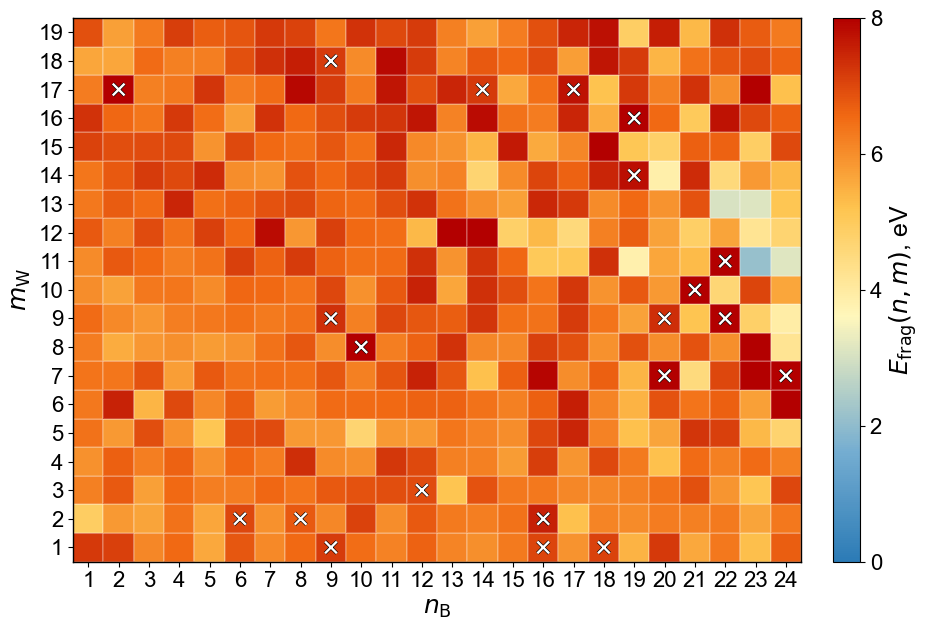

In [10]:
# =========================================================
# Final fragmentation colormap
# =========================================================
frag_cmap = LinearSegmentedColormap.from_list(
    "wb_frag",
    [
        (0.00, "#2c7bb6"),
        (0.20, "#74add1"),
        (0.45, "#fff7bc"),
        (0.65, "#fec44f"),
        (0.82, "#f16913"),
        (1.00, "#b30000"),
    ],
)

frag_vmin = 0.0
frag_vmax = 8.0

x_edges_frag = make_edges(b_array_plot)
y_edges_frag = make_edges(w_array_plot)

fig, ax = plt.subplots(figsize=(9.4, 6.4))

mesh = ax.pcolormesh(
    x_edges_frag,
    y_edges_frag,
    e_frag_plot,
    cmap=frag_cmap,
    vmin=frag_vmin,
    vmax=frag_vmax,
    shading="flat",
    edgecolors=(1, 1, 1, 0.20),
    linewidth=0.04,
    antialiased=False,
)

ax.set_xticks(b_array_plot)
ax.set_yticks(w_array_plot)
ax.set_xlabel(r"$n_{\mathrm{B}}$", fontsize=18)
ax.set_ylabel(r"$m_{\mathrm{W}}$", fontsize=18)
ax.tick_params(axis="both", labelsize=16)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

if selected_on_fragmentation:
    x_sel = [n_b for (m_w, n_b) in selected_on_fragmentation]
    y_sel = [m_w for (m_w, n_b) in selected_on_fragmentation]

    sc = ax.scatter(
        x_sel,
        y_sel,
        marker="x",
        s=72,
        linewidths=1.7,
        color="white",
        zorder=6,
    )
    sc.set_path_effects([
        pe.Stroke(linewidth=2.6, foreground="black"),
        pe.Normal(),
    ])

cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"$E_{\mathrm{frag}}(n,m)$, eV", fontsize=18)
cbar.ax.tick_params(labelsize=16)
cbar.set_ticks([0, 2, 4, 6, 8])

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fragmentation_map.png", dpi=600, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "fragmentation_map.pdf", bbox_inches="tight")
plt.show()

In [11]:
selected_fragmentation_df = selected_values_to_dataframe(
    selected_on_fragmentation,
    e_frag_plot,
    w_array_plot,
    b_array_plot,
    "E_frag_eV",
)

selected_fragmentation_df.to_csv(OUTPUT_DIR / "selected_fragmentation_values.csv", index=False)
selected_fragmentation_df

,m_W,n_B,formula,E_frag_eV
0,1,9,WB9,7.1756
1,1,16,WB16,7.0496
2,1,18,WB18,7.0913
3,2,6,W2B6,7.0193
4,2,8,W2B8,6.7553
5,2,16,W2B16,7.5390
6,3,12,W3B12,6.9564
7,7,20,W7B20,8.5628
8,7,24,W7B24,8.0764
9,8,10,W8B10,8.3068


## 6. Combined table for selected compositions

In [12]:
selected_combined_df = pd.merge(
    selected_stability_df,
    selected_fragmentation_df,
    on=["m_W", "n_B", "formula"],
    how="outer",
)

selected_combined_df = selected_combined_df.sort_values(["m_W", "n_B"]).reset_index(drop=True)
selected_combined_df.to_csv(OUTPUT_DIR / "selected_stability_fragmentation_values.csv", index=False)
selected_combined_df

,m_W,n_B,formula,min_d2E_eV,E_frag_eV
0,1,9,WB9,0.6902,7.1756
1,1,16,WB16,0.8827,7.0496
2,1,18,WB18,1.6255,7.0913
3,2,6,W2B6,1.2116,7.0193
4,2,8,W2B8,0.6438,6.7553
5,2,16,W2B16,1.9726,7.5390
6,3,12,W3B12,1.7802,6.9564
7,7,20,W7B20,2.8297,8.5628
8,7,24,W7B24,2.7617,8.0764
9,8,10,W8B10,2.2643,8.3068
